<a href="https://colab.research.google.com/github/laya7171/ML_tranning/blob/main/K_means_Clusturing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(n_samples=500, n_features= 2, centers= 3, random_state= 23)

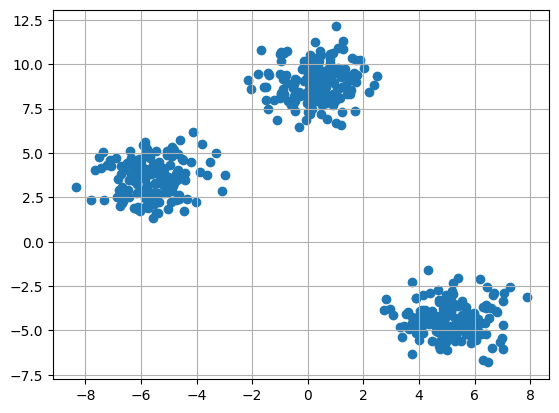

In [8]:
fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()


In [13]:
k = 3

clusters ={}
np.random.seed(23)

In [14]:
for idx in range(k):
  center  = 2*(2*np.random.random((X.shape[1],))-1)
  points = []
  cluster = {
      'center':center,
      'points':[]
  }

  clusters[idx] = cluster

In [15]:
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

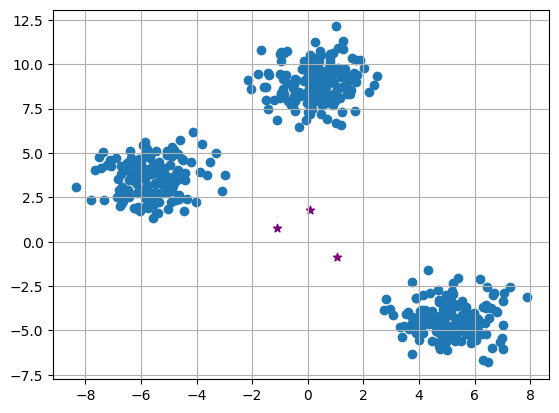

In [17]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
  center = clusters[i]['center']
  plt.scatter(center[0],center[1],marker= "*", c = 'purple')
plt.show()

In [24]:
def distance(p1,p2):
  return np.sqrt(np.sum((p1 - p2)**2))

In [29]:
def assign_clusters(X, clusters):
  for idx in range(X.shape[0]):
    dist = []

    curr_x = X[idx]

    for i in range(k):
      dis = distance(curr_x,clusters[i]['center'])
      dist.append(dis)
    curr_cluster = np.argmin(dis)
    clusters[curr_cluster]['points'].append(curr_x)
  return clusters



In [30]:
  def update_clusters(X,clusters):
    for i in range(k):
      points = np.array(clusters[i]['points'])
      if points.shape[0]>0:
        new_center = points.mean(axis=0)
        clusters[i]['center'] = new_center

        clusters[i]['points'] = []
    return clusters

In [32]:
def pred_cluster(X,clusters):
  pred = []
  for i in range(X.shape[0]):
    dist = []
    for j in range(k):
      dist.append(distance(X[i],clusters[j]['center']))
    pred.append(np.argmin(dist))
  return  pred

In [33]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

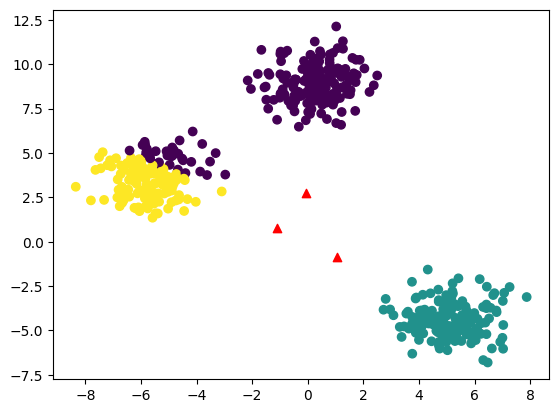

In [35]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
  center = clusters[i]['center']
  plt.scatter(center[0],center[1],marker = '^', c= 'red')
plt.show()